# CME Futures — Exploratory Data Analysis

**Docker image**: `ml4t`

**Purpose**: Profile the 30-product CME futures dataset (Databento, hourly,
2011–2025) and surface the contract / continuous structure that downstream
notebooks rely on.

**Learning objectives**:

- Understand the futures data hierarchy: product → contract → continuous series.
- Load individual contracts and continuous (rolled) series via
  `load_cme_futures` and inspect the canonical `timestamp` / `product`
  schema.
- Summarize per-product coverage and group products by asset class.
- Verify OHLC invariants on a representative continuous series.

**Book reference**: §2.2 ("The Asset-Class Market Data Landscape" — Futures).

**Prerequisites**: `data` package on `PYTHONPATH`; CME parquet present at
`ML4T_DATA_PATH/futures/`. Run `python data/futures/market/download.py` if
missing (Databento API key required).

In [1]:
"""CME Futures — Exploratory data analysis of the futures universe."""

import plotly.graph_objects as go
import polars as pl

from data import list_cme_products, load_cme_futures
from utils.data_quality import check_ohlc_invariants
from utils.style import COLORS

In [2]:
# Production defaults — Papermill injects overrides for CI
MAX_SYMBOLS = 0  # 0 = all

## 1. Configuration and Data Discovery

The futures data uses a Hive-partitioned structure for efficient queries:
- `futures/continuous/product={PRODUCT}/`: Volume-rolled continuous contracts (hourly)
- `futures/individual/{PRODUCT}/data.parquet`: Individual contract price data

We use `load_cme_futures()` for proper data loading with partition pruning.

In [3]:
# Discover available products via the CME loader
products = list_cme_products()

print("=== Futures Universe ===")
print(f"Available products: {len(products)}")
print(f"\nProducts: {', '.join(products)}")

=== Futures Universe ===
Available products: 30

Products: 6A, 6B, 6C, 6E, 6J, 6S, CL, ES, GC, GF, HE, HG, HO, LE, NG, NQ, PL, RB, RTY, SI, YM, ZB, ZC, ZF, ZL, ZM, ZN, ZS, ZT, ZW


Map each product to a coarse asset-class bucket. The mapping covers every
product in the dataset; downstream chapters use the same bucket labels for
universe-construction and risk reporting.

In [4]:
ASSET_CLASS_MAP = {
    "ES": "Equity Index",
    "NQ": "Equity Index",
    "YM": "Equity Index",
    "RTY": "Equity Index",
    "ZN": "Rates",
    "ZB": "Rates",
    "ZF": "Rates",
    "ZT": "Rates",
    "CL": "Energy",
    "NG": "Energy",
    "HO": "Energy",
    "RB": "Energy",
    "GC": "Metals",
    "SI": "Metals",
    "HG": "Metals",
    "PL": "Metals",
    "6E": "FX",
    "6J": "FX",
    "6B": "FX",
    "6A": "FX",
    "6C": "FX",
    "6S": "FX",
    "ZC": "Grains",
    "ZS": "Grains",
    "ZW": "Grains",
    "ZM": "Grains",
    "ZL": "Grains",
    "LE": "Livestock",
    "HE": "Livestock",
    "GF": "Livestock",
}

# One on-brand color per asset-class bucket, reused by every chart below so a
# bucket keeps the same color across the notebook.
ASSET_CLASS_COLORS = {
    "Equity Index": COLORS["blue"],
    "Rates": COLORS["amber"],
    "Energy": COLORS["copper"],
    "Metals": COLORS["slate"],
    "FX": COLORS["neutral"],
    "Grains": COLORS["positive"],
    "Livestock": COLORS["blue_light"],
}

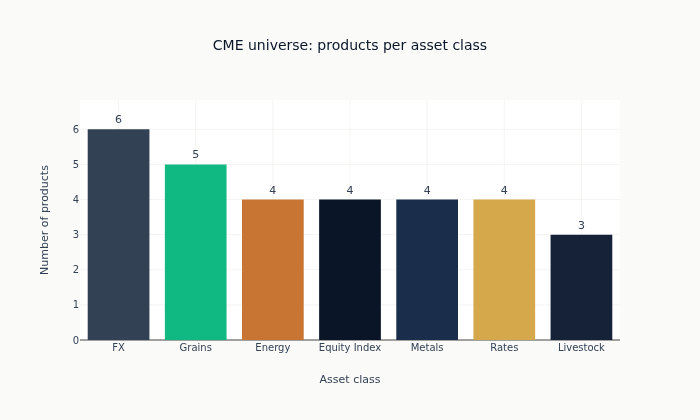

In [5]:
class_counts = (
    pl.DataFrame({"product": products})
    .with_columns(asset_class=pl.col("product").replace(ASSET_CLASS_MAP))
    .group_by("asset_class")
    .len()
    .sort(["len", "asset_class"], descending=[True, False])
)

fig = go.Figure(
    go.Bar(
        x=class_counts["asset_class"].to_list(),
        y=class_counts["len"].to_list(),
        marker_color=[ASSET_CLASS_COLORS[c] for c in class_counts["asset_class"].to_list()],
        text=class_counts["len"].to_list(),
        textposition="outside",
    )
)
fig.update_layout(
    title="CME universe: products per asset class",
    xaxis_title="Asset class",
    yaxis_title="Number of products",
    height=420,
    showlegend=False,
)
fig.show()

## 2. Data Structure Example: E-mini S&P 500 (ES)

### Futures Key Hierarchy

| Level | Example | Description |
|-------|---------|-------------|
| **Product** | ES | The underlying (E-mini S&P 500) |
| **Contract** | ESH4 | Specific expiration (March 2024) |
| **Continuous** | c0, c1 | Front month, first deferred |

In [6]:
es_individual = load_cme_futures(products=["ES"], continuous=False, frequency="hourly")

print("=== ES Individual Contracts ===")
print(f"Shape: {es_individual.shape}")
print(f"Columns: {es_individual.columns}")
print(f"Date range: {es_individual['timestamp'].min()} to {es_individual['timestamp'].max()}")
print(f"Unique contracts: {es_individual['instrument_id'].n_unique()}")

=== ES Individual Contracts ===
Shape: (19361, 10)
Columns: ['timestamp', 'rtype', 'publisher_id', 'instrument_id', 'open', 'high', 'low', 'close', 'volume', 'product']
Date range: 2016-01-03 00:00:00+00:00 to 2025-12-30 00:00:00+00:00
Unique contracts: 194


In [7]:
es_continuous = load_cme_futures(products=["ES"], tenors=[0], continuous=True, frequency="hourly")

print("=== ES Continuous Series (front month) ===")
print(f"Shape: {es_continuous.shape}")
print(f"Date range: {es_continuous['timestamp'].min()} to {es_continuous['timestamp'].max()}")

=== ES Continuous Series (front month) ===
Shape: (89031, 13)
Date range: 2011-01-02 23:00:00+00:00 to 2025-12-30 23:00:00+00:00


The front-month continuous series splices successive contracts into a single
price history. Plotted at daily resolution, it runs unbroken across the full
2011–2025 window — the volume-roll splicing leaves no visible gaps.

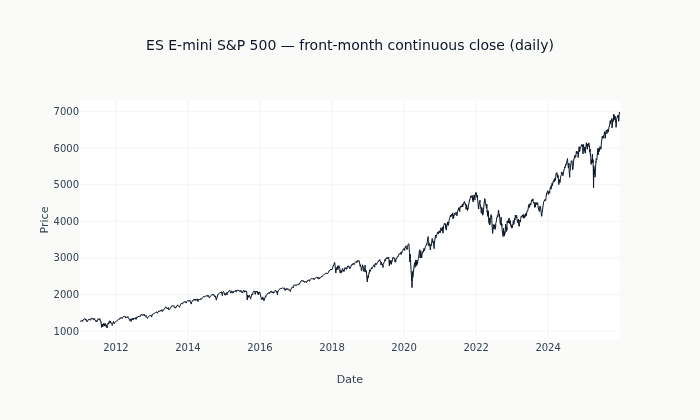

In [8]:
es_daily = (
    es_continuous.sort("timestamp")
    .group_by(pl.col("timestamp").dt.date().alias("date"), maintain_order=True)
    .agg(pl.col("close").last())
)

fig = go.Figure(
    go.Scatter(
        x=es_daily["date"].to_list(),
        y=es_daily["close"].to_list(),
        mode="lines",
        line=dict(color=COLORS["blue"], width=1),
        name="ES front month",
    )
)
fig.update_layout(
    title="ES E-mini S&P 500 — front-month continuous close (daily)",
    xaxis_title="Date",
    yaxis_title="Price",
    height=420,
)
fig.show()

Each individual contract trades for a finite window before expiry. Aggregating
by `instrument_id` shows the rollover pattern — quarterly contracts overlap
during the roll period.

In [9]:
contract_stats = (
    es_individual.group_by("instrument_id")
    .agg(
        pl.col("timestamp").min().alias("first_trade"),
        pl.col("timestamp").max().alias("last_trade"),
        pl.col("volume").sum().alias("total_volume"),
        pl.len().alias("observations"),
    )
    .sort("first_trade")
)
print(f"Total ES contracts: {len(contract_stats)}")

Total ES contracts: 194


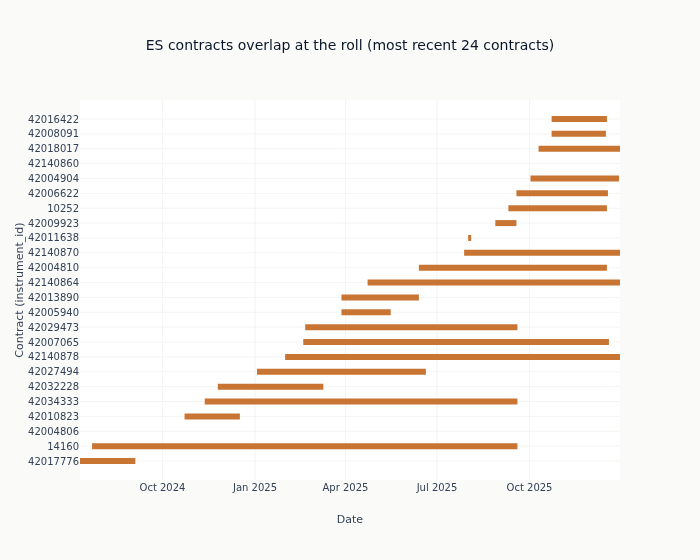

In [10]:
# Draw each of the most recent 24 contracts as a horizontal bar spanning its
# trading window. The overlap between neighboring bars is the roll period, when
# both the expiring and the next contract trade at once.
recent = contract_stats.tail(24)

fig = go.Figure()
for row in recent.iter_rows(named=True):
    fig.add_trace(
        go.Scatter(
            x=[row["first_trade"], row["last_trade"]],
            y=[str(row["instrument_id"]), str(row["instrument_id"])],
            mode="lines",
            line=dict(color=COLORS["copper"], width=6),
            showlegend=False,
        )
    )
fig.update_layout(
    title="ES contracts overlap at the roll (most recent 24 contracts)",
    xaxis_title="Date",
    yaxis_title="Contract (instrument_id)",
    yaxis=dict(type="category"),
    height=560,
)
fig.show()

## 3. Coverage Summary

Check data availability across all products.

Summarize per-product coverage by loading the front-month continuous series
(`tenor=0`) for every product and recording its row count and date range.

In [11]:
def get_product_coverage(product_list: list[str]) -> pl.DataFrame:
    """Summarize continuous series coverage for each product (front month)."""
    summaries = []
    for product in product_list:
        df = load_cme_futures(products=[product], tenors=[0], continuous=True, frequency="hourly")
        summaries.append(
            {
                "product": product,
                "asset_class": ASSET_CLASS_MAP[product],
                "rows": len(df),
                "start_date": str(df["timestamp"].min())[:10],
                "end_date": str(df["timestamp"].max())[:10],
            }
        )
    return pl.DataFrame(summaries)

In [12]:
coverage = get_product_coverage(products)
print(f"Products with data: {len(coverage)} / {len(products)}")

Products with data: 30 / 30


One horizontal bar per product spans its continuous front-month history, sorted
and colored by asset class. Most products cover the full 2011–2025 window; the
late-starting ones entered the dataset when Databento began capturing them.

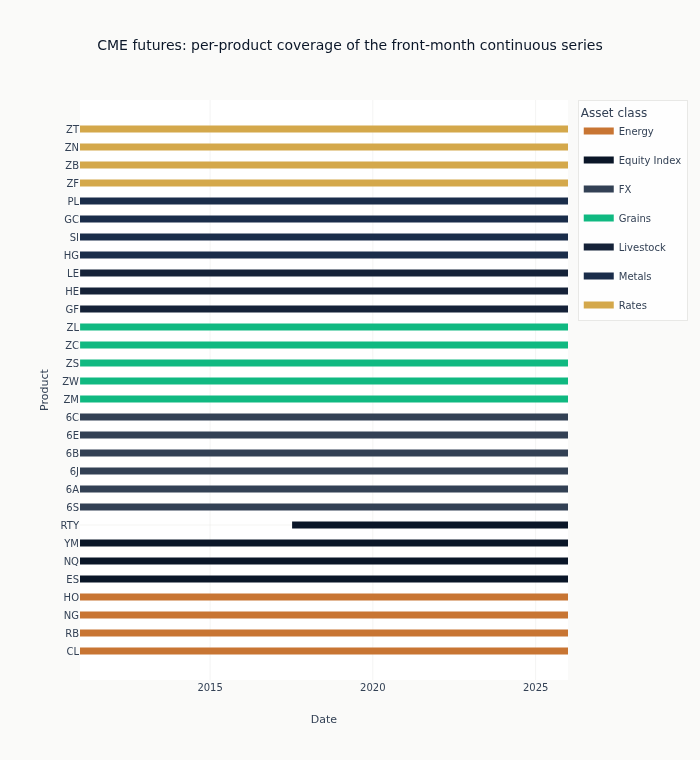

In [13]:
cov_timeline = coverage.with_columns(
    pl.col("start_date").str.to_date(),
    pl.col("end_date").str.to_date(),
).sort(["asset_class", "start_date"])

fig = go.Figure()
seen: set[str] = set()
for row in cov_timeline.iter_rows(named=True):
    cls = row["asset_class"]
    fig.add_trace(
        go.Scatter(
            x=[row["start_date"], row["end_date"]],
            y=[row["product"], row["product"]],
            mode="lines",
            line=dict(color=ASSET_CLASS_COLORS[cls], width=7),
            name=cls,
            legendgroup=cls,
            showlegend=cls not in seen,
        )
    )
    seen.add(cls)
fig.update_layout(
    title="CME futures: per-product coverage of the front-month continuous series",
    xaxis_title="Date",
    yaxis_title="Product",
    height=760,
    legend_title="Asset class",
)
fig.show()

## 4. Data Quality

In [14]:
invariants = check_ohlc_invariants(es_continuous)
print("=== OHLC Invariants (ES Continuous) ===")
for row in invariants.iter_rows(named=True):
    status = "[OK]" if row["valid_pct"] >= 99.99 else "[WARN]"
    print(f"  {status} {row['check']}: {row['valid_pct']:.2f}%")

=== OHLC Invariants (ES Continuous) ===
  [OK] high_gte_low: 100.00%
  [OK] high_gte_open: 100.00%
  [OK] high_gte_close: 100.00%
  [OK] low_lte_open: 100.00%
  [OK] low_lte_close: 100.00%
  [OK] volume_non_negative: 100.00%


## Key Takeaways

1. **30 products across 7 asset-class buckets**: FX (6), Grains (5),
   Energy / Equity Index / Metals / Rates (4 each), Livestock (3).
2. **Hierarchy**: each product has 100+ individual contracts (194 for ES) and
   one or more continuous series; downstream notebooks operate on the
   continuous front month unless they specifically need contract-level data.
3. **Hourly granularity**, full coverage 2011-01-02 through 2025-12-30 for
   products with the longest history. ES individual contract data starts
   later (2016) because earlier contracts have already rolled off.
4. **Canonical schema**: `timestamp` for time and `product` for entity (CME's
   contract identity is non-trivial — see also `instrument_id` for individual
   contracts).
5. **OHLC invariants hold at 100% for ES continuous** — all six checks pass
   on every observation.

### Next Steps

- **`05_futures_session_aggregation`**: Aligning hourly bars to CME trading
  sessions.
- **`06_futures_continuous`**: Roll detection and the three adjustment
  methods (ratio, difference, calendar).
- **Chapter 8**: Feature engineering on term structure and roll yield.